# Preprocessing and Modeling

In [3]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
RSEED = 50


In [4]:
#https://www.kaggle.com/competitions/playground-series-s6e4/overview
data_train = pd.read_csv("../data/playground-series-s6e4/train.csv")
eval_data_test = pd.read_csv("../data/playground-series-s6e4/test.csv")

data_train.shape


(630000, 21)

In [5]:
eval_data_test.shape

(270000, 20)

In [6]:
data_train_X = data_train.drop(columns=["id" , "Irrigation_Need"])
data_train_y = data_train["Irrigation_Need"]

eval_data_test_x = eval_data_test.drop(columns=["id"])

data_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
eval_data_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [8]:
data_train_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

# Splitting data

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_train_X, data_train_y, test_size=0.30, random_state=RSEED,stratify=data_train_y)

X_train.shape 

(441000, 19)

In [10]:
y_train.shape

(441000,)

# Feature Engineering

In [11]:
#transforming the categorical variable using one-hot encoding
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
numeric_cols = X_train.columns.difference(categorical_cols)

# 2. Fit on TRAIN
encoder = OneHotEncoder(handle_unknown='ignore' ,drop='first', sparse_output=False)

train_X_cat = encoder.fit_transform(X_train[categorical_cols])

# 3. Transform TEST (no fit!)
test_X_cat = encoder.transform(X_test[categorical_cols])

# 4. Combine numerical and categorical columns
feature_names = encoder.get_feature_names_out(categorical_cols)

train_X_cat_df = pd.DataFrame(train_X_cat, columns=feature_names, index=X_train.index)
test_X_cat_df = pd.DataFrame(test_X_cat, columns=feature_names, index=X_test.index)

train_X_final = pd.concat([X_train[numeric_cols], train_X_cat_df], axis=1)
test_X_final = pd.concat([X_test[numeric_cols], test_X_cat_df], axis=1)

In [12]:
#Exporting files
train_X_final.info()
train_X_final.to_csv("../data/train_test_data/train_X_final.csv", index=False)
test_X_final.to_csv("../data/train_test_data/test_X_final.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
Index: 441000 entries, 359466 to 587952
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Electrical_Conductivity       441000 non-null  float64
 1   Field_Area_hectare            441000 non-null  float64
 2   Humidity                      441000 non-null  float64
 3   Organic_Carbon                441000 non-null  float64
 4   Previous_Irrigation_mm        441000 non-null  float64
 5   Rainfall_mm                   441000 non-null  float64
 6   Soil_Moisture                 441000 non-null  float64
 7   Soil_pH                       441000 non-null  float64
 8   Sunlight_Hours                441000 non-null  float64
 9   Temperature_C                 441000 non-null  float64
 10  Wind_Speed_kmh                441000 non-null  float64
 11  Soil_Type_Loamy               441000 non-null  float64
 12  Soil_Type_Sandy               441000 non-nul

In [13]:
#label encoding 

"""

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)



"""



'\n\nfrom sklearn.preprocessing import LabelEncoder\n\nencoder = LabelEncoder()\n\ny_train_encoded = encoder.fit_transform(y_train)\ny_test_encoded = encoder.transform(y_test)\n\n\n\n'

In [14]:
mapping= {'Low': 0, 'Medium': 1, 'High': 2}

y_train_encoded = y_train.map(mapping)
y_test_encoded = y_test.map(mapping)


In [15]:
y_train_encoded.shape

y_train_encoded.to_csv("../data/train_test_data/y_train_encoded.csv", index=False)

In [16]:
#Normalizing numerical values
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


col_scale = numeric_cols 
scaler = MinMaxScaler()
scaling_transformation = ColumnTransformer(
    [("scaling", scaler, col_scale)], remainder="passthrough"
)

scaling_transformation.fit(train_X_final)



ColumnTransformer(remainder='passthrough',
                  transformers=[('scaling', MinMaxScaler(),
                                 Index(['Electrical_Conductivity', 'Field_Area_hectare', 'Humidity',
       'Organic_Carbon', 'Previous_Irrigation_mm', 'Rainfall_mm',
       'Soil_Moisture', 'Soil_pH', 'Sunlight_Hours', 'Temperature_C',
       'Wind_Speed_kmh'],
      dtype='object'))])

# Baseline

In [17]:
rf_low, rf_high = train_X_final["Rainfall_mm"].quantile([0.33, 0.66])
sm_low, sm_high = train_X_final["Soil_Moisture"].quantile([0.33, 0.66])
temp_low, temp_high = train_X_final["Temperature_C"].quantile([0.33, 0.66])
ws_low, ws_high = train_X_final["Wind_Speed_kmh"].quantile([0.33, 0.66])

def heuristic_model(row):

    Rainfall = row['Rainfall_mm']
    Soil_Moisture = row['Soil_Moisture']
    Temperature = row['Temperature_C']
    Wind_Speed = row['Wind_Speed_kmh']

    if (Soil_Moisture < sm_low) and (Temperature > temp_high) and (Rainfall < rf_low) and (Wind_Speed > ws_high):
        return 2  #high need for irrigation
    elif (sm_low <= Soil_Moisture <= sm_high) and (temp_low <= Temperature <= temp_high) and (rf_low <= Rainfall <= rf_high) and (ws_low <= Wind_Speed <= ws_high):
        return 1  # Medium need for irrig
    else:
        return 0  # Low need for irrig
    

y_pred_baseline = test_X_final.apply(heuristic_model, axis=1)
y_pred_baseline_valdiation = eval_data_test.apply(heuristic_model, axis=1)  
#y_pred_prob_bl = np.where(np.array(y_pred_baseline)=='Good Health', 0, 1)    

In [18]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve, accuracy_score
from sklearn.metrics import classification_report
print("Accuracy baseline: ", accuracy_score(y_test_encoded, y_pred_baseline))

print("classification report baseline: ", classification_report(y_test_encoded, y_pred_baseline))



Accuracy baseline:  0.5875714285714285
classification report baseline:                precision    recall  f1-score   support

           0       0.59      0.98      0.74    110975
           1       0.21      0.01      0.01     71722
           2       0.45      0.22      0.30      6303

    accuracy                           0.59    189000
   macro avg       0.42      0.40      0.35    189000
weighted avg       0.44      0.59      0.45    189000



Confusion matrix, without normalization


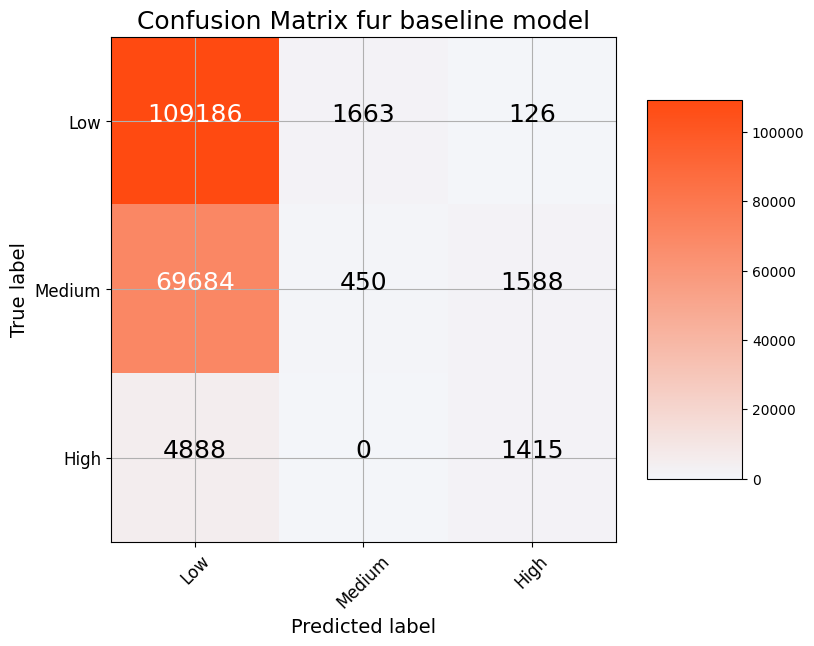

In [19]:
#Confusion Matrix
import sys
import os
sys.path.append(os.path.abspath(".."))
#import helper and plotting function
from src import helper_and_plotting_functions
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred_baseline)
helper_and_plotting_functions.plot_confusion_matrix(cm, classes=['Low', 'Medium', 'High'],normalize=False ,
                      title = 'Confusion Matrix fur baseline model')

In [20]:
#traning Random Forest 

from sklearn.ensemble import RandomForestClassifier
#{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.6, 'max_depth': 35, 'bootstrap': True}
rfClassifier = RandomForestClassifier(n_estimators=300,
                               min_samples_split=10,
                               min_samples_leaf=4,
                               max_features=0.6,
                               max_depth=35, 
                               random_state=RSEED, 
                               bootstrap=True,
                               class_weight = 'balanced',
                               n_jobs=-1, verbose = 1)

randomForestClassifier_scaled = Pipeline(
    [("scaling_trans", scaling_transformation), ("random_forest", rfClassifier)]
)

randomForestClassifier_scaled.fit(train_X_final, y_train_encoded)




              

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   38.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  4.9min finished


Pipeline(steps=[('scaling_trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', MinMaxScaler(),
                                                  Index(['Electrical_Conductivity', 'Field_Area_hectare', 'Humidity',
       'Organic_Carbon', 'Previous_Irrigation_mm', 'Rainfall_mm',
       'Soil_Moisture', 'Soil_pH', 'Sunlight_Hours', 'Temperature_C',
       'Wind_Speed_kmh'],
      dtype='object'))])),
                ('random_forest',
                 RandomForestClassifier(class_weight='balanced', max_depth=35,
                                        max_features=0.6, min_samples_leaf=4,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=50,
                                        verbose=1))])

In [21]:
from sklearn.metrics import f1_score
print("Accuracy Random Forest: ",  randomForestClassifier_scaled.score(test_X_final, y_test_encoded))
y_pred = randomForestClassifier_scaled.predict(test_X_final)
print("F1 Score macro Random Forest: ", f1_score(y_test_encoded, y_pred, average='macro'))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.5s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.5s finished


Accuracy Random Forest:  0.9851481481481481


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.7s


F1 Score macro Random Forest:  0.9704528151719459


[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.8s finished


In [22]:

depths = [tree.tree_.max_depth for tree in rfClassifier.estimators_]
avg_depth = np.mean(depths)

print("Average tree depth:", avg_depth)


leaves = [tree.tree_.n_leaves for tree in rfClassifier.estimators_]
avg_leaves = np.mean(leaves)

print("Average number of leaves:", avg_leaves)



Average tree depth: 34.196666666666665
Average number of leaves: 4296.243333333333


In [ ]:
print("--Traning set")
from sklearn.metrics import f1_score , precision_score, recall_score , roc_auc_score 

y_pred_train = randomForestClassifier_scaled.predict(train_X_final)

y_proba_train = randomForestClassifier_scaled.predict_proba(train_X_final)

print("Accuracy Random Forest: ",  randomForestClassifier_scaled.score(train_X_final, y_train_encoded))
print("F1 Score Random Forest: ", f1_score(y_train_encoded, y_pred_train, average='macro'))
print("Precision Random Forest: ", precision_score(y_train_encoded, y_pred_train, average='macro'))
print("Recall Random Forest: ", recall_score(y_train_encoded, y_pred_train, average='macro'))

print("ROC AUC Random Forest: ", roc_auc_score(y_train_encoded, y_proba_train, multi_class='ovr', average='macro'))

--Traning set


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.9s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    4.1s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    6.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.8s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    4.3s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    6.9s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.8s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    4.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    6.2s finished


Accuracy Random Forest:  0.9889591836734694
F1 Score macro Random Forest:  0.9859553399629712
Precision Random Forest:  0.9822040823150537
Recall Random Forest:  0.9899202606728027
ROC AUC Random Forest:  0.9998399689313328


In [ ]:
print( "--Validation set")
from sklearn.metrics import f1_score , precision_score, recall_score , roc_auc_score 

y_pred = randomForestClassifier_scaled.predict(test_X_final)

y_proba = randomForestClassifier_scaled.predict_proba(test_X_final)

print("Accuracy Random Forest: ",  randomForestClassifier_scaled.score(test_X_final, y_test_encoded))
print("F1 Score Random Forest: ", f1_score(y_test_encoded, y_pred, average='macro'))
print("Precision Random Forest: ", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall Random Forest: ", recall_score(y_test_encoded, y_pred, average='macro'))

print("ROC AUC Random Forest: ", roc_auc_score(y_test_encoded, y_proba, multi_class='ovr', average='macro'))

--Validation set


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.6s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.7s finished


Accuracy Random Forest:  0.9851481481481481
F1 Score macro Random Forest:  0.9704528151719459
Precision Random Forest:  0.9766256625470717
Recall Random Forest:  0.9645263940864273
ROC AUC Random Forest:  0.9962856655415889


In [25]:
#testing Random Forest 
from sklearn.metrics import classification_report

y_pred = randomForestClassifier_scaled.predict(test_X_final)

print(classification_report(y_test_encoded, y_pred))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    1.6s


              precision    recall  f1-score   support

           0       0.99      1.00      0.99    110975
           1       0.99      0.97      0.98     71722
           2       0.96      0.92      0.94      6303

    accuracy                           0.99    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.99      0.99      0.99    189000



[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    2.6s finished


Confusion matrix, without normalization


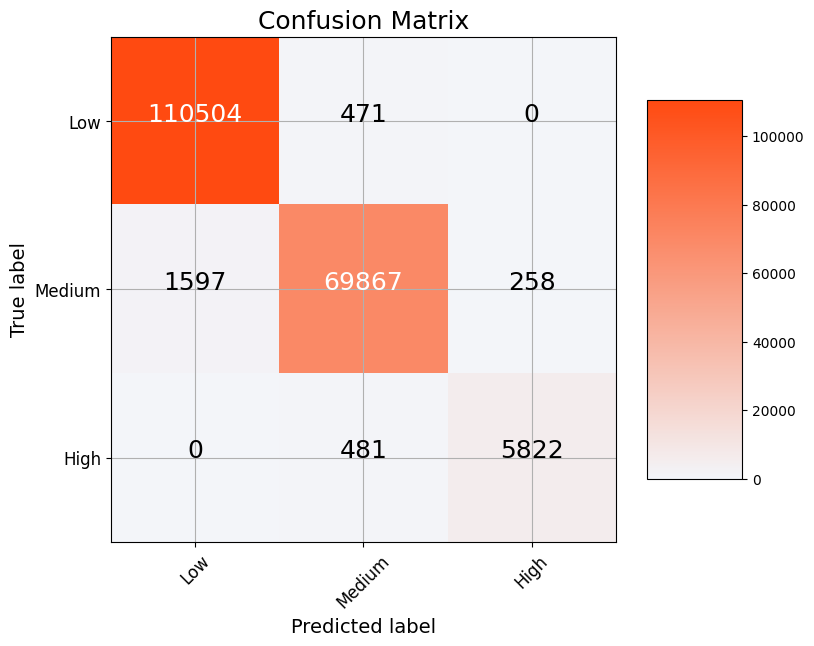

In [26]:
#Confusion Matrix
import sys
import os
sys.path.append(os.path.abspath(".."))
#import helper and plotting function
from src import helper_and_plotting_functions
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)
helper_and_plotting_functions.plot_confusion_matrix(cm, classes=['Low', 'Medium', 'High'],
                      title = 'Confusion Matrix')

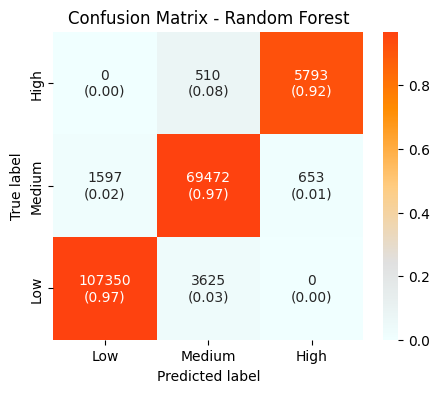

In [39]:
cm_heu = cm 
annot_heu = np.empty_like(cm_heu).astype(str)

cm_heu_norm = cm_heu.astype('float') / cm_heu.sum(axis=1)[:, np.newaxis]
for i in range(cm_heu.shape[0]):
   for j in range(cm_heu.shape[1]):
       annot_heu[i, j] = f"{cm_heu[i, j]}\n({cm_heu_norm[i, j]:.2f})"




from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
   "gray_to_orange",
   ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))


sns.heatmap(cm_heu_norm, cmap=cmap, annot=annot_heu, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - Random Forest")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()

# AdaBoost

In [29]:
from sklearn.ensemble import AdaBoostClassifier

AdaBoostClassifier().get_params()

{'algorithm': 'SAMME.R',
 'base_estimator': 'deprecated',
 'estimator': None,
 'learning_rate': 1.0,
 'n_estimators': 50,
 'random_state': None}

In [30]:
#traning Adaboost

from sklearn.ensemble import AdaBoostClassifier

#Hyperparameter tuning:{'n_estimators': 120, 'learning_rate': 1.0}

adaClassifier = AdaBoostClassifier(n_estimators=120,
                               learning_rate=1.0, 
                               random_state=RSEED)

adaBoostClassifier_scaled = Pipeline(
    [("scaling_trans", scaling_transformation), ("adaBoost", adaClassifier)]
)

adaBoostClassifier_scaled.fit(train_X_final, y_train_encoded)



Pipeline(steps=[('scaling_trans',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', MinMaxScaler(),
                                                  Index(['Electrical_Conductivity', 'Field_Area_hectare', 'Humidity',
       'Organic_Carbon', 'Previous_Irrigation_mm', 'Rainfall_mm',
       'Soil_Moisture', 'Soil_pH', 'Sunlight_Hours', 'Temperature_C',
       'Wind_Speed_kmh'],
      dtype='object'))])),
                ('adaBoost',
                 AdaBoostClassifier(n_estimators=120, random_state=50))])

In [31]:
print("Accuracy adaBoost: ",  adaBoostClassifier_scaled.score(test_X_final, y_test_encoded))


Accuracy adaBoost:  0.9662169312169312


In [33]:
from sklearn.metrics import f1_score , precision_score, recall_score , roc_auc_score 

y_pred_train = adaBoostClassifier_scaled.predict(train_X_final)
print ("--Traning set-- ")

print("Accuracy adaBoost: ",  adaBoostClassifier_scaled.score(train_X_final, y_train_encoded))
print("F1 Score adaBoost: ", f1_score(y_train_encoded, y_pred_train, average='macro'))
print("Precision adaBoost: ", precision_score(y_train_encoded, y_pred_train, average='macro'))
print("Recall adaBoost: ", recall_score(y_train_encoded, y_pred_train, average='macro'))


--Traning set-- 
Accuracy adaBoost:  0.9658049886621315
F1 Score adaBoost:  0.9462594914972337
Precision adaBoost:  0.941346867916962
Recall adaBoost:  0.9514591894951759


In [34]:
from sklearn.metrics import f1_score , precision_score, recall_score , roc_auc_score 

y_pred = adaBoostClassifier_scaled.predict(test_X_final)

print("--Evaluation set-- ")
print("Accuracy adaBoost : ",  adaBoostClassifier_scaled.score(test_X_final, y_test_encoded))
print("F1 Score macro adaBoost: ", f1_score(y_test_encoded, y_pred, average='macro'))
print("Precision adaBoost: ", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall adaBoost: ", recall_score(y_test_encoded, y_pred, average='macro'))

--Evaluation set-- 
Accuracy adaBoost :  0.9662169312169312
F1 Score macro adaBoost:  0.9470325268436325
Precision adaBoost:  0.9426205467583179
Recall adaBoost:  0.9516833358003661


In [36]:
#Classification Report for Adaboost
from sklearn.metrics import classification_report

y_pred_ada = adaBoostClassifier_scaled.predict(test_X_final)

print(classification_report(y_test_encoded, y_pred_ada))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98    110975
           1       0.94      0.97      0.96     71722
           2       0.90      0.92      0.91      6303

    accuracy                           0.97    189000
   macro avg       0.94      0.95      0.95    189000
weighted avg       0.97      0.97      0.97    189000



Confusion matrix, without normalization


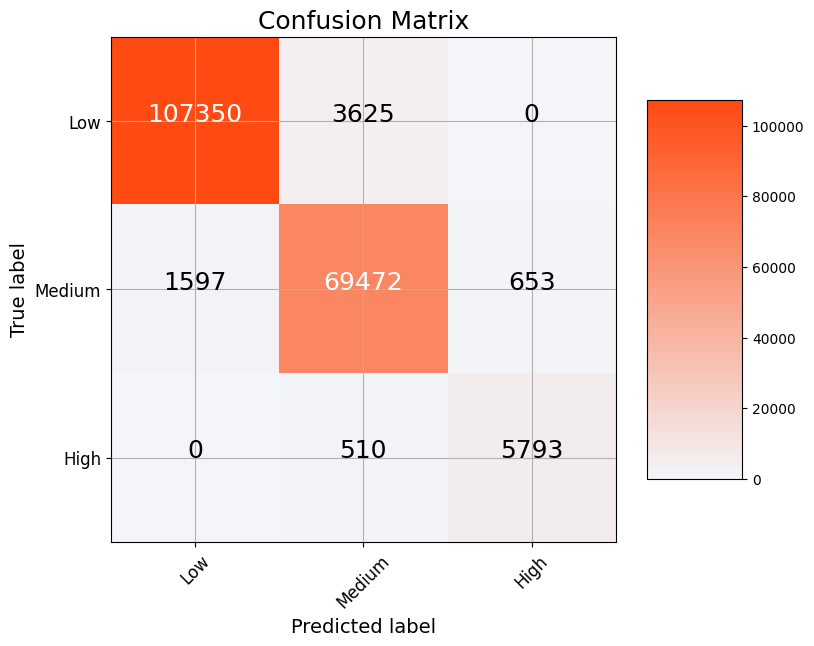

In [ ]:
#Confusion Matrix
import sys
import os
sys.path.append(os.path.abspath(".."))
#import helper and plotting function
from src import helper_and_plotting_functions
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred_ada)
helper_and_plotting_functions.plot_confusion_matrix(cm, classes=['Low', 'Medium', 'High'],normalize=True ,
                      title = 'Confusion Matrix')

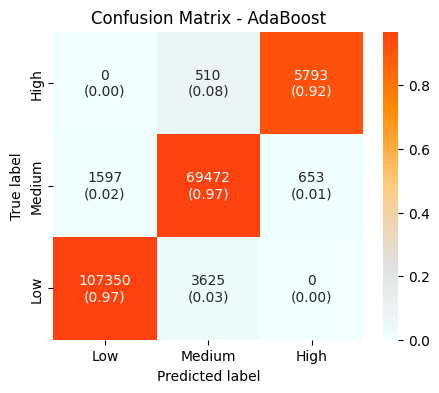

In [40]:
cm_heu = cm 
annot_heu = np.empty_like(cm_heu).astype(str)

cm_heu_norm = cm_heu.astype('float') / cm_heu.sum(axis=1)[:, np.newaxis]
for i in range(cm_heu.shape[0]):
   for j in range(cm_heu.shape[1]):
       annot_heu[i, j] = f"{cm_heu[i, j]}\n({cm_heu_norm[i, j]:.2f})"




from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
   "gray_to_orange",
   ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))


sns.heatmap(cm_heu_norm, cmap=cmap, annot=annot_heu, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - AdaBoost")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()